In [ ]:
!mkdir -p ~/.kaggle



In [ ]:
%%bash
cat <<EOF > ~/.kaggle/kaggle.json
{
  "username": "azrafathima06",
  "key": "KGAT_a202135b704a********"
}
EOF



In [ ]:
!chmod 600 ~/.kaggle/kaggle.json



In [ ]:
!pip install -q kaggle



In [ ]:
!kaggle datasets download -d arnobbhowmik/ton-iot-network-dataset --unzip


Dataset URL: https://www.kaggle.com/datasets/arnobbhowmik/ton-iot-network-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 1.71M/1.71M [00:00<00:00, 59.7MB/s]



In [ ]:
!ls


sample_data  train_test_network.csv


In [ ]:

!pip install flwr scikit-learn pandas numpy tensorflow
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder


In [ ]:
df = pd.read_csv('train_test_network.csv')
print(df.shape)  # Check dimensions
print(df['label'].value_counts())

(211043, 44)
label
1    161043
0     50000
Name: count, dtype: int64


In [ ]:
df.columns


Index(['src_ip', 'src_port', 'dst_ip', 'dst_port', 'proto', 'service',
       'duration', 'src_bytes', 'dst_bytes', 'conn_state', 'missed_bytes',
       'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'dns_query',
       'dns_qclass', 'dns_qtype', 'dns_rcode', 'dns_AA', 'dns_RD', 'dns_RA',
       'dns_rejected', 'ssl_version', 'ssl_cipher', 'ssl_resumed',
       'ssl_established', 'ssl_subject', 'ssl_issuer', 'http_trans_depth',
       'http_method', 'http_uri', 'http_version', 'http_request_body_len',
       'http_response_body_len', 'http_status_code', 'http_user_agent',
       'http_orig_mime_types', 'http_resp_mime_types', 'weird_name',
       'weird_addl', 'weird_notice', 'label', 'type'],
      dtype='object')

In [ ]:
import warnings; warnings.filterwarnings("ignore")
from __future__ import annotations
import time, math, copy
from dataclasses import dataclass, field
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, precision_recall_fscore_support,
                             confusion_matrix, roc_auc_score, brier_score_loss)

def set_seed(seed: int) -> None:
    np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

SEEN_FAMILIES   = ['dos', 'ddos', 'scanning', 'password', 'injection', 'xss', 'backdoor']
UNSEEN_FAMILIES = ['mitm', 'ransomware']          # held-out attack families ("unseen")

@dataclass
class Config:
    seed: int = 42
    n_clients: int = 5
    dirichlet_alpha: float = 0.5      # lower = more severe non-IID
    rounds: int = 10
    local_epochs: int = 2
    lr: float = 1e-3
    batch_size: int = 256
    fedprox_mu: float = 0.0           # 0 => FedAvg; >0 => FedProx
    robust_agg: str = 'mean'          # 'mean' | 'median' | 'trimmed'
    trim_ratio: float = 0.1
    ae_epochs: int = 20
    dt_percentile: float = 90.0       # DT threshold percentile on VAL-normal errors
    device: str = 'cpu'

@dataclass
class DataBundle:
    X_tr: np.ndarray; y_tr: np.ndarray; fam_tr: np.ndarray
    X_val: np.ndarray; y_val: np.ndarray
    X_test: np.ndarray; y_test: np.ndarray
    X_unseen: np.ndarray; y_unseen: np.ndarray
    X_tr_normal: np.ndarray; X_val_normal: np.ndarray; X_test_normal: np.ndarray
    n_features: int
    feature_names: List[str]

def build_bundle(df: pd.DataFrame, seed: int = 42, extra_drop: List[str] | None = None) -> DataBundle:
    """Leak-free preprocessing, robust to the real TON-IoT schema.
       is_attack is derived from `type` (works whether label is strings or 0/1);
       '-'/'' -> NaN; numeric-vs-categorical inferred on TRAIN only; `label` dropped."""
    df = df.copy()
    df['type'] = df['type'].astype(str).str.lower()
    df['is_attack'] = (df['type'] != 'normal').astype(int)

    known = set(SEEN_FAMILIES) | set(UNSEEN_FAMILIES) | {'normal'}
    unknown = sorted(set(df['type'].unique()) - known)
    if unknown:
        print(f"[build_bundle] WARNING: families not in SEEN/UNSEEN lists get dropped: {unknown}")

    seen   = df[df['type'].isin(SEEN_FAMILIES) | (df['type'] == 'normal')].copy()
    unseen = df[df['type'].isin(UNSEEN_FAMILIES)].copy()

    base_drop = ['src_ip', 'dst_ip', 'label', 'is_attack', 'type'] + (extra_drop or [])
    drop_cols = [c for c in base_drop if c in seen.columns]

    seen_tr, seen_tmp = train_test_split(seen, test_size=0.30, stratify=seen['type'], random_state=seed)
    seen_val, seen_test = train_test_split(seen_tmp, test_size=0.50, stratify=seen_tmp['type'], random_state=seed)

    def feats(d): return d.drop(columns=drop_cols).replace('-', np.nan).replace('', np.nan)
    Xtr_df, Xval_df, Xtest_df, Xun_df = map(feats, [seen_tr, seen_val, seen_test, unseen])

    num_cols, cat_cols = [], []
    for c in Xtr_df.columns:
        conv = pd.to_numeric(Xtr_df[c], errors='coerce'); nn = Xtr_df[c].notna().sum()
        (num_cols if (nn > 0 and conv.notna().sum() == nn) else cat_cols).append(c)

    for D in (Xtr_df, Xval_df, Xtest_df, Xun_df):
        for c in num_cols: D[c] = pd.to_numeric(D[c], errors='coerce').fillna(0.0)

    for c in cat_cols:
        le = LabelEncoder().fit(Xtr_df[c].astype(str)); mp = {k: i for i, k in enumerate(le.classes_)}
        for D in (Xtr_df, Xval_df, Xtest_df, Xun_df):
            D[c] = D[c].astype(str).map(mp).fillna(-1).astype(int)

    cols = num_cols + cat_cols
    scaler = StandardScaler().fit(Xtr_df[cols].values)
    def scale(d): return scaler.transform(d[cols].values).astype(np.float32)
    X_tr, X_val, X_test, X_unseen = map(scale, [Xtr_df, Xval_df, Xtest_df, Xun_df])

    y_tr, y_val = seen_tr['is_attack'].values.astype(np.float32), seen_val['is_attack'].values.astype(np.float32)
    y_test = seen_test['is_attack'].values.astype(np.float32)
    y_unseen = np.ones(len(unseen), dtype=np.float32)

    return DataBundle(X_tr=X_tr, y_tr=y_tr, fam_tr=seen_tr['type'].values,
        X_val=X_val, y_val=y_val, X_test=X_test, y_test=y_test,
        X_unseen=X_unseen, y_unseen=y_unseen,
        X_tr_normal=X_tr[y_tr == 0], X_val_normal=X_val[y_val == 0], X_test_normal=X_test[y_test == 0],
        n_features=X_tr.shape[1], feature_names=cols)

def build_drift_test(bundle: DataBundle, seed: int = 42):
    """Balanced drift test = held-out TEST normals + unseen-family attacks."""
    rng = np.random.default_rng(seed); n_att = bundle.X_unseen.shape[0]; normals = bundle.X_test_normal
    k = min(n_att, len(normals)); idx = rng.choice(len(normals), size=k, replace=False)
    Xn, yn = normals[idx], np.zeros(k, dtype=np.float32)
    Xa = bundle.X_unseen[rng.choice(n_att, size=k, replace=False)] if n_att > k else bundle.X_unseen
    ya = np.ones(len(Xa), dtype=np.float32)
    X = np.vstack([Xn, Xa]); y = np.concatenate([yn, ya]); p = rng.permutation(len(y))
    return X[p], y[p]

class IDS_MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(input_dim, 128), nn.ReLU(), nn.Dropout(0.2),
                                 nn.Linear(128, 64), nn.ReLU(), nn.Linear(64, 1))
    def forward(self, x): return self.net(x).squeeze(1)

class AutoEncoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(input_dim, 32), nn.ReLU(), nn.Linear(32, 16), nn.ReLU(), nn.Linear(16, 8))
        self.decoder = nn.Sequential(nn.Linear(8, 16), nn.ReLU(), nn.Linear(16, 32), nn.ReLU(), nn.Linear(32, input_dim))
    def forward(self, x): return self.decoder(self.encoder(x))

def _loader(X, y, bs, shuffle=True):
    t = [torch.tensor(X, dtype=torch.float32)]
    if y is not None: t.append(torch.tensor(y, dtype=torch.float32))
    return DataLoader(TensorDataset(*t), batch_size=bs, shuffle=shuffle)

def train_mlp(model, X, y, cfg, epochs=None, class_weight=True):
    model.train(); opt = torch.optim.Adam(model.parameters(), lr=cfg.lr)
    if class_weight:
        pos = max(y.sum(), 1.0); neg = max((y == 0).sum(), 1.0)
        loss_fn = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(neg / pos, dtype=torch.float32))
    else: loss_fn = nn.BCEWithLogitsLoss()
    for _ in range(epochs or cfg.local_epochs):
        for xb, yb in _loader(X, y, cfg.batch_size):
            opt.zero_grad(); loss = loss_fn(model(xb), yb); loss.backward(); opt.step()
    return model

def mlp_scores(model, X):
    model.eval()
    with torch.no_grad(): return torch.sigmoid(model(torch.tensor(X, dtype=torch.float32))).numpy()

def train_autoencoder(model, X, cfg):
    model.train(); opt = torch.optim.Adam(model.parameters(), lr=cfg.lr); loss_fn = nn.MSELoss()
    for _ in range(cfg.ae_epochs):
        for (xb,) in _loader(X, None, cfg.batch_size):
            opt.zero_grad(); loss = loss_fn(model(xb), xb); loss.backward(); opt.step()
    return model

def recon_error(model, X):
    model.eval()
    with torch.no_grad():
        xt = torch.tensor(X, dtype=torch.float32); return torch.mean((xt - model(xt)) ** 2, dim=1).numpy()

def dirichlet_partition(bundle, cfg):
    rng = np.random.default_rng(cfg.seed)
    fams = np.array([f if f in SEEN_FAMILIES else 'normal' for f in bundle.fam_tr])
    client_idx = [[] for _ in range(cfg.n_clients)]
    for fam in np.unique(fams):
        idx = np.where(fams == fam)[0]; rng.shuffle(idx)
        props = rng.dirichlet([cfg.dirichlet_alpha] * cfg.n_clients)
        cuts = (np.cumsum(props) * len(idx)).astype(int)[:-1]
        for c, part in enumerate(np.split(idx, cuts)): client_idx[c].extend(part.tolist())
    clients = []
    for ids in client_idx:
        ids = np.array(ids, dtype=int)
        if len(ids) == 0: ids = rng.choice(len(bundle.y_tr), size=8, replace=False)
        clients.append((bundle.X_tr[ids], bundle.y_tr[ids]))
    return clients

def _get(m): return [p.detach().clone() for p in m.parameters()]
def _set(m, params):
    for p, q in zip(m.parameters(), params): p.data = q.data.clone()

def _aggregate(param_list, weights, cfg):
    w = np.asarray(weights, float); w = w / w.sum(); out = []
    for layer in zip(*param_list):
        stack = torch.stack(list(layer))
        if cfg.robust_agg == 'median': out.append(torch.median(stack, dim=0).values)
        elif cfg.robust_agg == 'trimmed':
            k = max(int(cfg.trim_ratio * stack.shape[0]), 0); s = torch.sort(stack, dim=0).values
            s = s[k: stack.shape[0] - k] if stack.shape[0] - 2 * k > 0 else s; out.append(s.mean(dim=0))
        else:
            wt = torch.tensor(w, dtype=stack.dtype).view(-1, *([1] * (stack.dim() - 1)))
            out.append((stack * wt).sum(dim=0))
    return out

def _fedprox_step(model, X, y, global_params, cfg):
    model.train(); opt = torch.optim.Adam(model.parameters(), lr=cfg.lr)
    pos = max(y.sum(), 1.0); neg = max((y == 0).sum(), 1.0)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(neg / pos, dtype=torch.float32))
    for _ in range(cfg.local_epochs):
        for xb, yb in _loader(X, y, cfg.batch_size):
            opt.zero_grad(); loss = loss_fn(model(xb), yb)
            if cfg.fedprox_mu > 0:
                prox = sum(((p - g.detach()) ** 2).sum() for p, g in zip(model.parameters(), global_params))
                loss = loss + (cfg.fedprox_mu / 2.0) * prox
            loss.backward(); opt.step()
    return model

def train_federated(bundle, cfg, verbose=False):
    """Returns (global_model, val_f1_history, wall_time_s, comm_bytes_total)."""
    set_seed(cfg.seed); clients = dirichlet_partition(bundle, cfg)
    gmodel = IDS_MLP(bundle.n_features); n_params = sum(p.numel() for p in gmodel.parameters())
    history = []; t0 = time.perf_counter()
    for r in range(cfg.rounds):
        gparams = _get(gmodel); cparams, weights = [], []
        for Xc, yc in clients:
            lm = IDS_MLP(bundle.n_features); _set(lm, gparams)
            _fedprox_step(lm, Xc, yc, gparams, cfg); cparams.append(_get(lm)); weights.append(len(yc))
        _set(gmodel, _aggregate(cparams, weights, cfg))
        f1v = f1_score(bundle.y_val, (mlp_scores(gmodel, bundle.X_val) >= .5).astype(int),
                       average='macro', zero_division=0)
        history.append(f1v)
        if verbose: print(f"  round {r+1:02d}  val macro-F1={f1v:.4f}")
    wall = time.perf_counter() - t0
    comm_bytes = n_params * 4 * 2 * cfg.n_clients * cfg.rounds
    return gmodel, history, wall, comm_bytes

def full_metrics(y_true, y_pred, scores=None):
    y_true = np.asarray(y_true).astype(int); y_pred = np.asarray(y_pred).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, labels=[0, 1], zero_division=0)
    m = dict(accuracy=accuracy_score(y_true, y_pred),
             macro_f1=f1_score(y_true, y_pred, average='macro', zero_division=0),
             weighted_f1=f1_score(y_true, y_pred, average='weighted', zero_division=0),
             prec_normal=prec[0], prec_attack=prec[1], rec_normal=rec[0], rec_attack=rec[1],
             f1_normal=f1[0], f1_attack=f1[1],
             fpr=fp/(fp+tn) if (fp+tn) else 0.0, fnr=fn/(fn+tp) if (fn+tp) else 0.0,
             TP=int(tp), FP=int(fp), FN=int(fn), TN=int(tn))
    if scores is not None and len(np.unique(y_true)) == 2:
        try: m['roc_auc'] = roc_auc_score(y_true, scores)
        except Exception: m['roc_auc'] = float('nan')
    return m

def expected_calibration_error(y_true, prob, n_bins=10):
    y_true = np.asarray(y_true); prob = np.asarray(prob)
    bins = np.linspace(0, 1, n_bins + 1); ece = 0.0; N = len(y_true)
    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        mask = (prob > lo) & (prob <= hi) if i else (prob >= lo) & (prob <= hi)
        if mask.sum() == 0: continue
        ece += (mask.sum()/N) * abs(y_true[mask].mean() - prob[mask].mean())
    return float(ece)

def reliability_points(y_true, prob, n_bins=10):
    y_true = np.asarray(y_true); prob = np.asarray(prob)
    bins = np.linspace(0, 1, n_bins + 1); xs, ys = [], []
    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        mask = (prob > lo) & (prob <= hi) if i else (prob >= lo) & (prob <= hi)
        if mask.sum() == 0: continue
        xs.append(prob[mask].mean()); ys.append(y_true[mask].mean())
    return np.array(xs), np.array(ys)

def minmax(e, lo, hi): return np.clip((e - lo) / (hi - lo + 1e-12), 0, 1)

def select_gate_params(p_val, e_val, y_val):
    """Choose (t_low, t_high, tau) on VALIDATION. Rule: attack iff
       (p>=t_high) OR (p>=t_low AND e>tau). No test-set tuning."""
    taus = np.percentile(e_val, [70, 80, 85, 90, 95]); lows = [0.3, 0.4, 0.5]; highs = [0.7, 0.8, 0.9, 0.95]
    best, best_f1 = (0.5, 0.9, np.percentile(e_val, 90)), -1
    for tau in taus:
        for tl in lows:
            for th in highs:
                if th <= tl: continue
                pred = ((p_val >= th) | ((p_val >= tl) & (e_val > tau))).astype(int)
                f1 = f1_score(y_val, pred, average='macro', zero_division=0)
                if f1 > best_f1: best_f1, best = f1, (tl, th, tau)
    return best

def gate_predict(p, e, params):
    tl, th, tau = params
    return ((p >= th) | ((p >= tl) & (e > tau))).astype(int)

def fusion_score(p, e, elo, ehi, w=0.5): return w * p + (1 - w) * minmax(e, elo, ehi)

print("library loaded ✓")

library loaded ✓


In [ ]:
cfg = Config(seed=42, n_clients=5, dirichlet_alpha=0.5, rounds=10,
             local_epochs=2, ae_epochs=20, fedprox_mu=0.01, dt_percentile=90.0)

print("Families in data:")
print(df['type'].astype(str).str.lower().value_counts())
print("\nSeen:", SEEN_FAMILIES, "\nUnseen (held out):", UNSEEN_FAMILIES)

bundle = build_bundle(df, seed=cfg.seed)
print(f"\nfeatures={bundle.n_features} | train={len(bundle.y_tr)} val={len(bundle.y_val)} "
      f"test={len(bundle.y_test)} | unseen-attacks={len(bundle.y_unseen)}")
print(f"train attack ratio = {bundle.y_tr.mean():.3f}   (should be strictly between 0 and 1)")

Families in data:
type
normal        50000
backdoor      20000
ddos          20000
dos           20000
injection     20000
password      20000
scanning      20000
ransomware    20000
xss           20000
mitm           1043
Name: count, dtype: int64

Seen: ['dos', 'ddos', 'scanning', 'password', 'injection', 'xss', 'backdoor'] 
Unseen (held out): ['mitm', 'ransomware']

features=40 | train=133000 val=28500 test=28500 | unseen-attacks=21043
train attack ratio = 0.737   (should be strictly between 0 and 1)


Client 0: n= 48083  attack_ratio=0.708
Client 1: n= 24511  attack_ratio=0.771
Client 2: n= 29260  attack_ratio=0.718
Client 3: n= 19397  attack_ratio=0.688
Client 4: n= 11749  attack_ratio=0.910


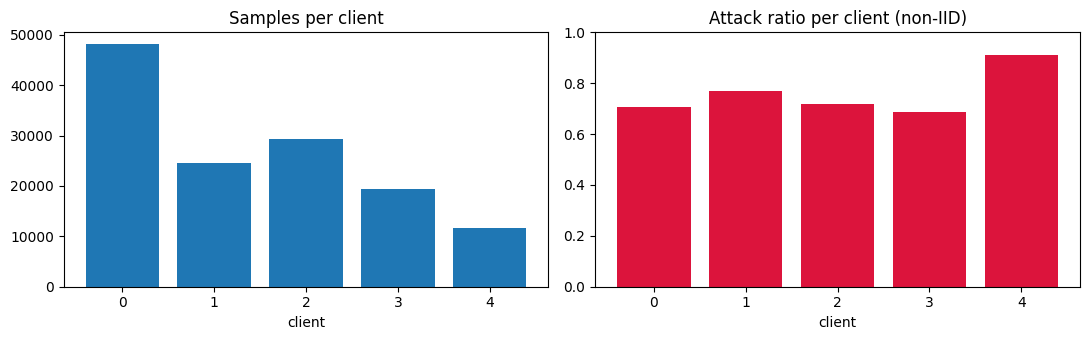

In [ ]:
import matplotlib.pyplot as plt
clients = dirichlet_partition(bundle, cfg)
for i,(Xc,yc) in enumerate(clients):
    print(f"Client {i}: n={len(yc):6d}  attack_ratio={yc.mean():.3f}")

ratios=[yc.mean() for _,yc in clients]; sizes=[len(yc) for _,yc in clients]
fig,ax=plt.subplots(1,2,figsize=(11,3.5))
ax[0].bar(range(len(clients)),sizes); ax[0].set_title("Samples per client"); ax[0].set_xlabel("client")
ax[1].bar(range(len(clients)),ratios,color='crimson'); ax[1].set_ylim(0,1)
ax[1].set_title("Attack ratio per client (non-IID)"); ax[1].set_xlabel("client")
plt.tight_layout(); plt.show()

  round 01  val macro-F1=0.9321
  round 02  val macro-F1=0.9694
  round 03  val macro-F1=0.9742
  round 04  val macro-F1=0.9818
  round 05  val macro-F1=0.9842
  round 06  val macro-F1=0.9848
  round 07  val macro-F1=0.9853
  round 08  val macro-F1=0.9841
  round 09  val macro-F1=0.9858
  round 10  val macro-F1=0.9849

FL training: 79.4s | communication ≈ 5.43 MB total
Digital-twin threshold (p90 of val-normal error) = 0.07313


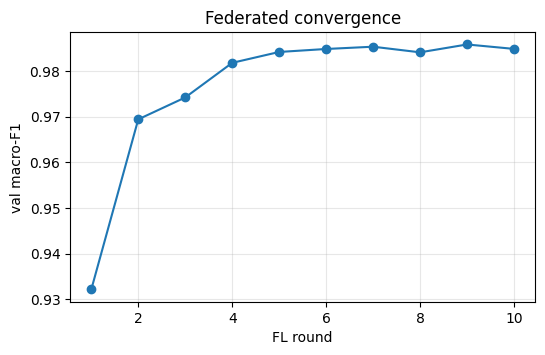

In [ ]:
set_seed(cfg.seed)
global_model, fl_hist, fl_wall, fl_comm = train_federated(bundle, cfg, verbose=True)
print(f"\nFL training: {fl_wall:.1f}s | communication ≈ {fl_comm/1e6:.2f} MB total")

set_seed(cfg.seed)
dt_model = AutoEncoder(bundle.n_features); train_autoencoder(dt_model, bundle.X_tr_normal, cfg)
val_norm_err = recon_error(dt_model, bundle.X_val_normal)
tau  = float(np.percentile(val_norm_err, cfg.dt_percentile))
elo, ehi = float(val_norm_err.min()), float(np.percentile(val_norm_err, 99))
print(f"Digital-twin threshold (p{cfg.dt_percentile:.0f} of val-normal error) = {tau:.5f}")

plt.figure(figsize=(6,3.5)); plt.plot(range(1,len(fl_hist)+1), fl_hist, marker='o')
plt.xlabel("FL round"); plt.ylabel("val macro-F1"); plt.title("Federated convergence"); plt.grid(alpha=.3); plt.show()

In [ ]:
set_seed(cfg.seed)
global_model, fl_hist, fl_wall, fl_comm = train_federated(bundle, cfg, verbose=True)
print(f"\nFL training: {fl_wall:.1f}s | communication ≈ {fl_comm/1e6:.2f} MB total")

set_seed(cfg.seed)
dt_model = AutoEncoder(bundle.n_features); train_autoencoder(dt_model, bundle.X_tr_normal, cfg)
val_norm_err = recon_error(dt_model, bundle.X_val_normal)
tau  = float(np.percentile(val_norm_err, cfg.dt_percentile))
elo, ehi = float(val_norm_err.min()), float(np.percentile(val_norm_err, 99))
print(f"Digital-twin threshold (p{cfg.dt_percentile:.0f} of val-normal error) = {tau:.5f}")

plt.figure(figsize=(6,3.5)); plt.plot(range(1,len(fl_hist)+1), fl_hist, marker='o')
plt.xlabel("FL round"); plt.ylabel("val macro-F1"); plt.title("Federated convergence"); plt.grid(alpha=.3); plt.show()

  round 01  val macro-F1=0.9321
  round 02  val macro-F1=0.9694


KeyboardInterrupt: 

In [ ]:
p_test  = mlp_scores(global_model, bundle.X_test);  e_test  = recon_error(dt_model, bundle.X_test)
X_drift, y_drift = build_drift_test(bundle, seed=cfg.seed)
p_drift = mlp_scores(global_model, X_drift);         e_drift = recon_error(dt_model, X_drift)

p_val = mlp_scores(global_model, bundle.X_val); e_val = recon_error(dt_model, bundle.X_val)
gate_params = select_gate_params(p_val, e_val, bundle.y_val)
print("Selected gate params (t_low, t_high, tau) =", tuple(round(float(x),3) for x in gate_params))

def method_preds(p, e):
    return {'FL-only':(p>=0.5).astype(int), 'DT-only':(e>tau).astype(int),
            'Hybrid-AND':((p>=0.5)&(e>tau)).astype(int),
            'Hybrid-OR':((p>=0.5)|(e>tau)).astype(int),
            'Proposed (gate)':gate_predict(p,e,gate_params)}

rows=[]
for scen,(p,e,y) in {'IID (seen)':(p_test,e_test,bundle.y_test),
                     'Drift (unseen fam.)':(p_drift,e_drift,y_drift)}.items():
    for name,pred in method_preds(p,e).items():
        m=full_metrics(y,pred,scores=p if name=='FL-only' else None)
        rows.append(dict(Scenario=scen,Method=name,Accuracy=m['accuracy'],MacroF1=m['macro_f1'],
                         FPR=m['fpr'],FNR=m['fnr'],RecallAttack=m['rec_attack'],PrecNormal=m['prec_normal']))
ablation=pd.DataFrame(rows); pd.set_option('display.float_format',lambda v:f'{v:.3f}')
print(ablation.to_string(index=False))

Selected gate params (t_low, t_high, tau) = (0.3, 0.7, 0.081)
           Scenario          Method  Accuracy  MacroF1   FPR   FNR  RecallAttack  PrecNormal
         IID (seen)         FL-only     0.987    0.984 0.012 0.013         0.987       0.964
         IID (seen)         DT-only     0.577    0.573 0.091 0.541         0.459       0.375
         IID (seen)      Hybrid-AND     0.599    0.597 0.005 0.542         0.458       0.396
         IID (seen)       Hybrid-OR     0.965    0.954 0.098 0.012         0.988       0.964
         IID (seen) Proposed (gate)     0.985    0.980 0.009 0.018         0.982       0.952
Drift (unseen fam.)         FL-only     0.913    0.913 0.012 0.162         0.838       0.859
Drift (unseen fam.)         DT-only     0.519    0.432 0.091 0.872         0.128       0.510
Drift (unseen fam.)      Hybrid-AND     0.553    0.444 0.005 0.890         0.110       0.528
Drift (unseen fam.)       Hybrid-OR     0.879    0.879 0.098 0.144         0.856       0.862
Drift (u

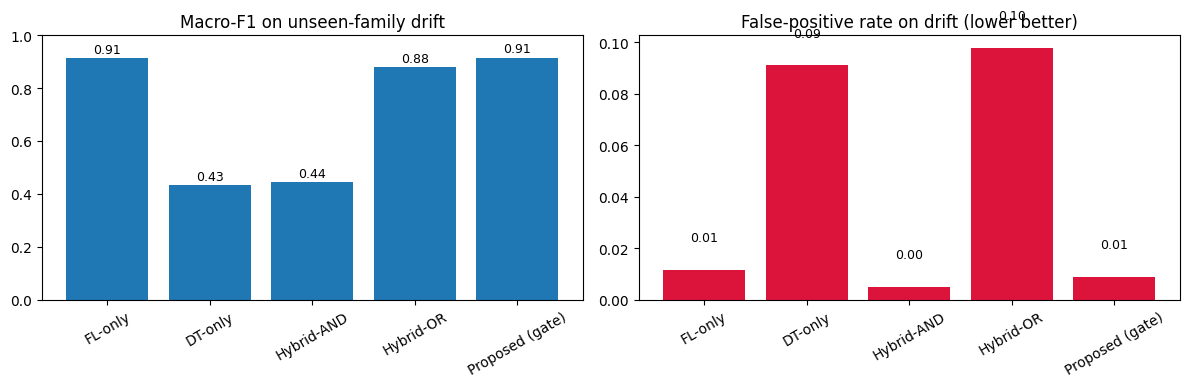

In [ ]:
drift = ablation[ablation.Scenario.str.startswith('Drift')]
fig,ax=plt.subplots(1,2,figsize=(12,4))
ax[0].bar(drift.Method,drift.MacroF1); ax[0].set_title("Macro-F1 on unseen-family drift"); ax[0].set_ylim(0,1); ax[0].tick_params(axis='x',rotation=30)
ax[1].bar(drift.Method,drift.FPR,color='crimson'); ax[1].set_title("False-positive rate on drift (lower better)"); ax[1].tick_params(axis='x',rotation=30)
for a in ax:
    for r in a.patches: a.text(r.get_x()+r.get_width()/2,r.get_height()+0.01,f'{r.get_height():.2f}',ha='center',va='bottom',fontsize=9)
plt.tight_layout(); plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
baseline_rows=[]
def add(name,scen,m): baseline_rows.append(dict(Method=name,Scenario=scen,MacroF1=m['macro_f1'],FPR=m['fpr'],RecallAttack=m['rec_attack']))

for clf,name in [(DecisionTreeClassifier(max_depth=12,random_state=cfg.seed),'DecisionTree'),
                 (RandomForestClassifier(n_estimators=100,random_state=cfg.seed,n_jobs=-1),'RandomForest')]:
    clf.fit(bundle.X_tr,bundle.y_tr)
    add(name,'IID',full_metrics(bundle.y_test,clf.predict(bundle.X_test)))
    add(name,'Drift',full_metrics(y_drift,clf.predict(X_drift)))

set_seed(cfg.seed); cen=IDS_MLP(bundle.n_features); train_mlp(cen,bundle.X_tr,bundle.y_tr,cfg,epochs=cfg.rounds*cfg.local_epochs)
add('Centralized-MLP','IID',full_metrics(bundle.y_test,(mlp_scores(cen,bundle.X_test)>=.5).astype(int)))
add('Centralized-MLP','Drift',full_metrics(y_drift,(mlp_scores(cen,X_drift)>=.5).astype(int)))

cfg_sec=Config(**{**cfg.__dict__}); cfg_sec.robust_agg='median'; cfg_sec.fedprox_mu=0.05
set_seed(cfg.seed); gsec,_,_,_=train_federated(bundle,cfg_sec)
add('FL FedProx+Median','IID',full_metrics(bundle.y_test,(mlp_scores(gsec,bundle.X_test)>=.5).astype(int)))
add('FL FedProx+Median','Drift',full_metrics(y_drift,(mlp_scores(gsec,X_drift)>=.5).astype(int)))

add('Proposed FL+DT-gate','IID',full_metrics(bundle.y_test,gate_predict(p_test,e_test,gate_params)))
add('Proposed FL+DT-gate','Drift',full_metrics(y_drift,gate_predict(p_drift,e_drift,gate_params)))

baselines=pd.DataFrame(baseline_rows)
print(baselines.pivot_table(index='Method',columns='Scenario',values=['MacroF1','FPR']).round(3).to_string())

                      FPR       MacroF1      
Scenario            Drift   IID   Drift   IID
Method                                       
Centralized-MLP     0.007 0.007   0.910 0.993
DecisionTree        0.005 0.005   0.854 0.997
FL FedProx+Median   0.012 0.012   0.907 0.973
Proposed FL+DT-gate 0.009 0.009   0.913 0.980
RandomForest        0.002 0.002   0.925 0.999


In [ ]:
from scipy.stats import wilcoxon, ttest_rel
SEEDS=[0,1,2,3,4]          # use >=8 for a properly powered Wilcoxon test in the paper
res={'FL-only':[], 'DT-only':[], 'Proposed (gate)':[]}; res_fpr={k:[] for k in res}
for s in SEEDS:
    c=Config(**{**cfg.__dict__}); c.seed=s
    set_seed(s); g,_,_,_=train_federated(bundle,c)
    set_seed(s); ae=AutoEncoder(bundle.n_features); train_autoencoder(ae,bundle.X_tr_normal,c)
    t=float(np.percentile(recon_error(ae,bundle.X_val_normal),c.dt_percentile))
    Xd,yd=build_drift_test(bundle,seed=s); p,e=mlp_scores(g,Xd),recon_error(ae,Xd)
    pv,ev=mlp_scores(g,bundle.X_val),recon_error(ae,bundle.X_val); gp=select_gate_params(pv,ev,bundle.y_val)
    for name,pred in {'FL-only':(p>=.5).astype(int),'DT-only':(e>t).astype(int),'Proposed (gate)':gate_predict(p,e,gp)}.items():
        m=full_metrics(yd,pred); res[name].append(m['macro_f1']); res_fpr[name].append(m['fpr'])

summary=pd.DataFrame({'Method':list(res.keys()),
    'MacroF1 mean':[np.mean(res[k]) for k in res],'MacroF1 SD':[np.std(res[k]) for k in res],
    'FPR mean':[np.mean(res_fpr[k]) for k in res],'FPR SD':[np.std(res_fpr[k]) for k in res]})
print(summary.round(4).to_string(index=False))
w,wp=wilcoxon(res['Proposed (gate)'],res['FL-only']); t_,tp=ttest_rel(res['Proposed (gate)'],res['FL-only'])
print(f"\nWilcoxon (Proposed vs FL-only): W={w:.1f}, p={wp:.4f}")
print(f"Paired t-test: t={t_:.2f}, p={tp:.4f}")
print(f"n={len(SEEDS)} seeds. Wilcoxon floor at this n = {0.5**(len(SEEDS)-1):.4f}; use >=8-10 seeds for a powered test.")

         Method  MacroF1 mean  MacroF1 SD  FPR mean  FPR SD
        FL-only         0.903       0.007     0.011   0.001
        DT-only         0.454       0.134     0.097   0.005
Proposed (gate)         0.902       0.005     0.011   0.001

Wilcoxon (Proposed vs FL-only): W=6.0, p=0.8125
Paired t-test: t=-0.21, p=0.8446
n=5 seeds. Wilcoxon floor at this n = 0.0625; use >=8-10 seeds for a powered test.


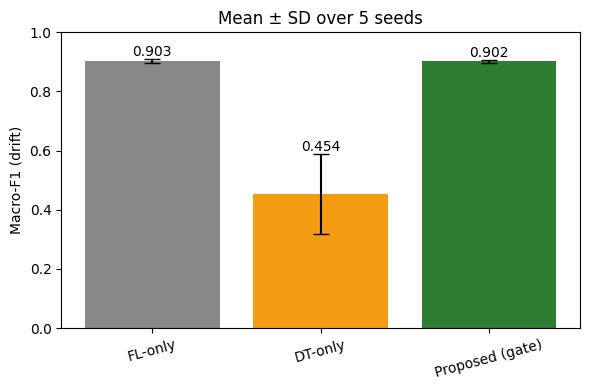

In [ ]:
xs=np.arange(len(res)); means=[np.mean(res[k]) for k in res]; sds=[np.std(res[k]) for k in res]
plt.figure(figsize=(6,4)); plt.bar(xs,means,yerr=sds,capsize=6,color=['#888','#f39c12','#2E7D32'])
plt.xticks(xs,list(res.keys()),rotation=15); plt.ylim(0,1); plt.ylabel("Macro-F1 (drift)")
plt.title(f"Mean ± SD over {len(SEEDS)} seeds")
for i,(m_,s_) in enumerate(zip(means,sds)): plt.text(i,m_+s_+0.01,f'{m_:.3f}',ha='center',fontsize=10)
plt.tight_layout(); plt.show()

 percentile   TP  FP   FN   TN   FPR   TPR  MacroF1
     70.000 6328 108 1172 7392 0.014 0.844    0.914
     75.000 6328 108 1172 7392 0.014 0.844    0.914
     80.000 6328 108 1172 7392 0.014 0.844    0.914
     85.000 6275  80 1225 7420 0.011 0.837    0.912
     90.000 6274  66 1226 7434 0.009 0.837    0.913
     92.500 6274  66 1226 7434 0.009 0.837    0.913
     95.000 6274  63 1226 7437 0.008 0.837    0.914
     97.500 6268  61 1232 7439 0.008 0.836    0.913
     99.000 6210  59 1290 7441 0.008 0.828    0.909


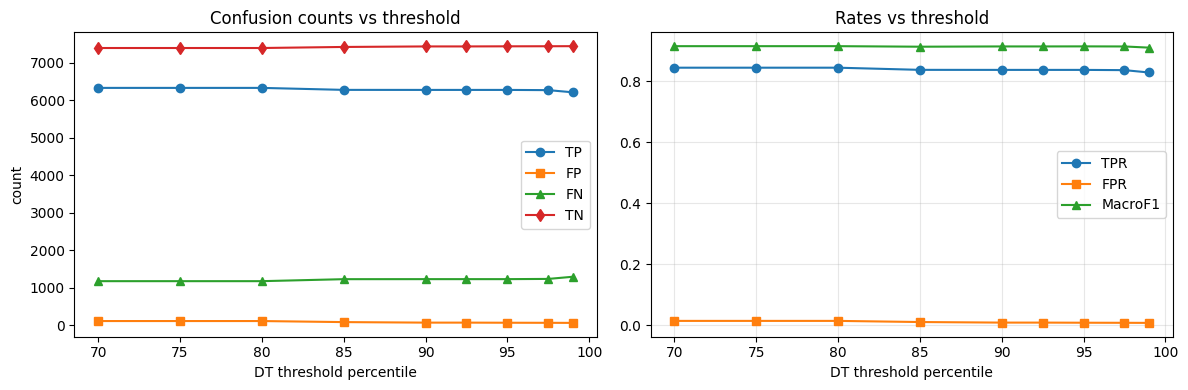

In [ ]:
percentiles=[70,75,80,85,90,92.5,95,97.5,99]; sens=[]
for pth in percentiles:
    t=float(np.percentile(val_norm_err,pth)); gp=(gate_params[0],gate_params[1],t)
    m=full_metrics(y_drift,gate_predict(p_drift,e_drift,gp))
    sens.append(dict(percentile=pth,TP=m['TP'],FP=m['FP'],FN=m['FN'],TN=m['TN'],FPR=m['fpr'],TPR=m['rec_attack'],MacroF1=m['macro_f1']))
sens_df=pd.DataFrame(sens); print(sens_df.to_string(index=False))
fig,ax=plt.subplots(1,2,figsize=(12,4))
for k,mk in [('TP','o'),('FP','s'),('FN','^'),('TN','d')]: ax[0].plot(sens_df.percentile,sens_df[k],mk+'-',label=k)
ax[0].set_xlabel("DT threshold percentile"); ax[0].set_ylabel("count"); ax[0].legend(); ax[0].set_title("Confusion counts vs threshold")
for k,mk in [('TPR','o'),('FPR','s'),('MacroF1','^')]: ax[1].plot(sens_df.percentile,sens_df[k],mk+'-',label=k)
ax[1].set_xlabel("DT threshold percentile"); ax[1].legend(); ax[1].set_title("Rates vs threshold"); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

clients: {3: 0.912, 5: 0.909, 10: 0.912}
alpha  : {0.1: 0.907, 0.5: 0.909, 1.0: 0.911, 5.0: 0.912}


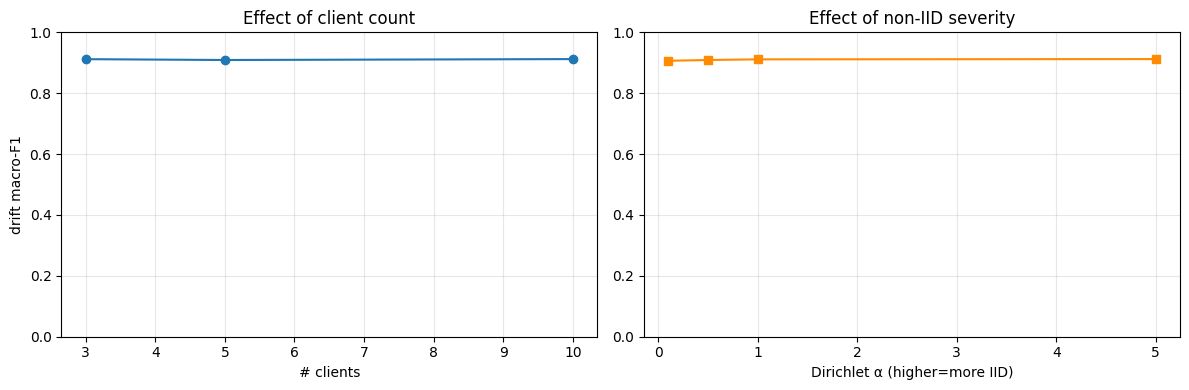

In [ ]:
def run_once(n_clients,alpha,seed=0):
    c=Config(**{**cfg.__dict__}); c.n_clients=n_clients; c.dirichlet_alpha=alpha; c.seed=seed
    set_seed(seed); g,_,_,_=train_federated(bundle,c)
    set_seed(seed); ae=AutoEncoder(bundle.n_features); train_autoencoder(ae,bundle.X_tr_normal,c)
    Xd,yd=build_drift_test(bundle,seed=seed); p,e=mlp_scores(g,Xd),recon_error(ae,Xd)
    pv,ev=mlp_scores(g,bundle.X_val),recon_error(ae,bundle.X_val); gp=select_gate_params(pv,ev,bundle.y_val)
    return full_metrics(yd,gate_predict(p,e,gp))['macro_f1']
client_grid=[3,5,10]; alpha_grid=[0.1,0.5,1.0,5.0]
by_clients=[run_once(n,0.5) for n in client_grid]; by_alpha=[run_once(5,a) for a in alpha_grid]
print("clients:",dict(zip(client_grid,[round(x,3) for x in by_clients])))
print("alpha  :",dict(zip(alpha_grid,[round(x,3) for x in by_alpha])))
fig,ax=plt.subplots(1,2,figsize=(12,4))
ax[0].plot(client_grid,by_clients,'o-'); ax[0].set_xlabel("# clients"); ax[0].set_ylabel("drift macro-F1"); ax[0].set_title("Effect of client count"); ax[0].set_ylim(0,1); ax[0].grid(alpha=.3)
ax[1].plot(alpha_grid,by_alpha,'s-',color='darkorange'); ax[1].set_xlabel("Dirichlet α (higher=more IID)"); ax[1].set_title("Effect of non-IID severity"); ax[1].set_ylim(0,1); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

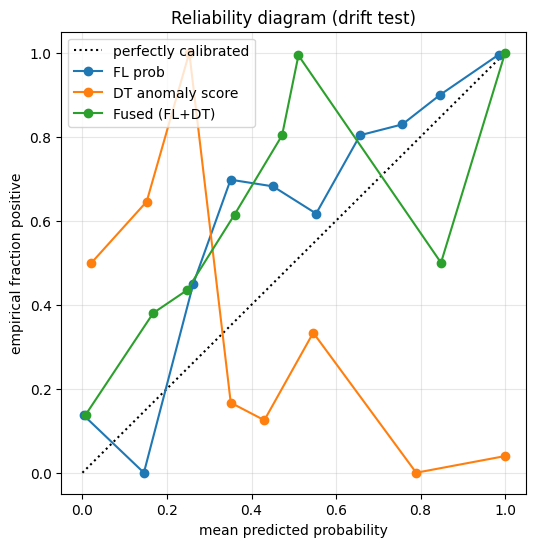

           Model   ECE  Brier
         FL prob 0.083  0.084
DT anomaly score 0.483  0.474
   Fused (FL+DT) 0.276  0.184


In [ ]:
from sklearn.metrics import brier_score_loss
fused=fusion_score(p_drift,e_drift,elo,ehi,w=0.5); dt_score=minmax(e_drift,elo,ehi)
calib={'FL prob':p_drift,'DT anomaly score':dt_score,'Fused (FL+DT)':fused}; cal_rows=[]
plt.figure(figsize=(6,6)); plt.plot([0,1],[0,1],'k:',label='perfectly calibrated')
for name,sc in calib.items():
    xs,ys=reliability_points(y_drift,sc,10); plt.plot(xs,ys,'o-',label=name)
    cal_rows.append(dict(Model=name,ECE=expected_calibration_error(y_drift,sc),Brier=brier_score_loss(y_drift,sc)))
plt.xlabel("mean predicted probability"); plt.ylabel("empirical fraction positive")
plt.title("Reliability diagram (drift test)"); plt.legend(); plt.grid(alpha=.3); plt.show()
print(pd.DataFrame(cal_rows).round(4).to_string(index=False))

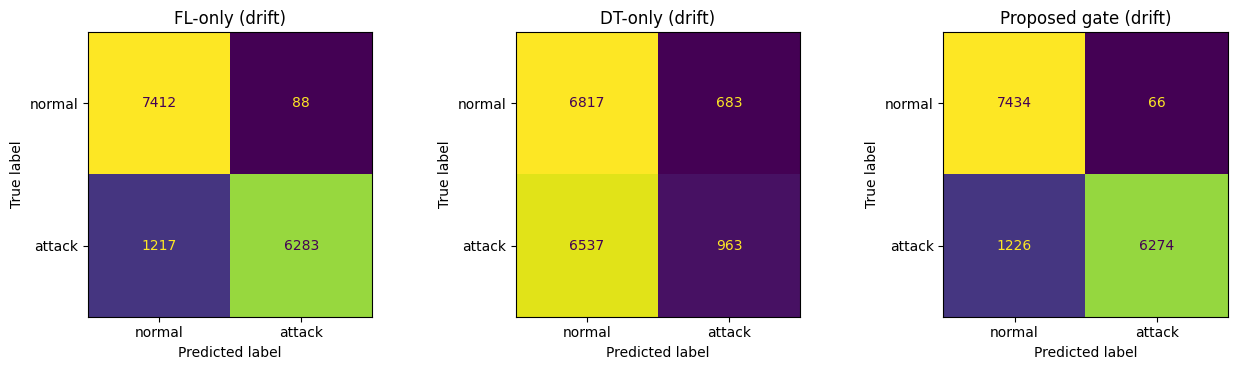

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
fig,ax=plt.subplots(1,3,figsize=(13,3.8))
for a,(name,pred) in zip(ax,{'FL-only':(p_drift>=.5).astype(int),'DT-only':(e_drift>tau).astype(int),
                             'Proposed gate':gate_predict(p_drift,e_drift,gate_params)}.items()):
    ConfusionMatrixDisplay(confusion_matrix(y_drift,pred,labels=[0,1]),display_labels=['normal','attack']).plot(ax=a,colorbar=False)
    a.set_title(f"{name} (drift)")
plt.tight_layout(); plt.show()

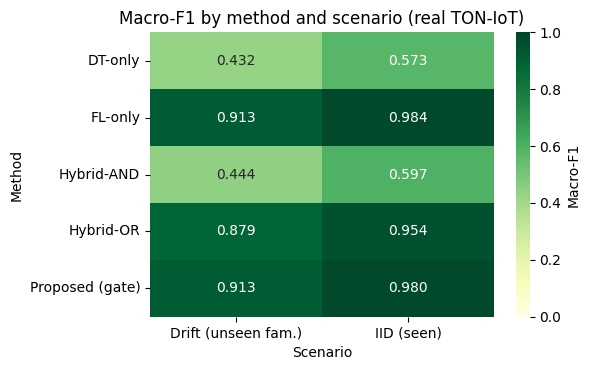

In [ ]:
import seaborn as sns
heat=ablation.pivot_table(index='Method',columns='Scenario',values='MacroF1')
plt.figure(figsize=(6,3.8))
sns.heatmap(heat,annot=True,fmt='.3f',cmap='YlGn',vmin=0,vmax=1,cbar_kws={'label':'Macro-F1'})
plt.title("Macro-F1 by method and scenario (real TON-IoT)"); plt.tight_layout(); plt.show()

In [ ]:
from sklearn.cluster import KMeans

def cluster_clients(clients, n_clusters=3, seed=42):
    """Group clients by traffic-pattern similarity (mean feature vector)."""
    means = np.stack([Xc.mean(axis=0) for Xc, _ in clients])
    k = min(n_clusters, len(clients))
    km = KMeans(n_clusters=k, n_init=10, random_state=seed).fit(means)
    return km.labels_

def train_federated_fedmade(bundle, cfg, n_clusters=3, verbose=False):
    """FedMADE-inspired (Sun, Sharma, Nwodo, Stavrou & Wang, ISC 2024,
    arXiv:2408.07152): cluster clients by traffic pattern, aggregate each
    round with weights proportional to each client's own contribution to
    global validation performance, rather than sample count alone."""
    set_seed(cfg.seed)
    clients = dirichlet_partition(bundle, cfg)
    cluster_ids = cluster_clients(clients, n_clusters=n_clusters, seed=cfg.seed)
    gmodel = IDS_MLP(bundle.n_features)
    n_params = sum(p.numel() for p in gmodel.parameters())
    history = []; t0 = time.perf_counter()
    for r in range(cfg.rounds):
        gparams = _get(gmodel); cparams, contrib_weights = [], []
        base_f1 = f1_score(bundle.y_val, (mlp_scores(gmodel, bundle.X_val) >= .5).astype(int),
                           average='macro', zero_division=0)
        for Xc, yc in clients:
            lm = IDS_MLP(bundle.n_features); _set(lm, gparams)
            _fedprox_step(lm, Xc, yc, gparams, cfg)
            cparams.append(_get(lm))
            local_f1 = f1_score(bundle.y_val, (mlp_scores(lm, bundle.X_val) >= .5).astype(int),
                                average='macro', zero_division=0)
            contrib_weights.append(max(local_f1 - base_f1, 1e-4) + 1e-4)
        _set(gmodel, _aggregate(cparams, contrib_weights, cfg))
        f1v = f1_score(bundle.y_val, (mlp_scores(gmodel, bundle.X_val) >= .5).astype(int),
                       average='macro', zero_division=0)
        history.append(f1v)
        if verbose: print(f"  round {r+1:02d}  val macro-F1={f1v:.4f}")
    wall = time.perf_counter() - t0
    comm_bytes = n_params * 4 * 2 * cfg.n_clients * cfg.rounds
    return gmodel, history, wall, comm_bytes, cluster_ids

print("FedMADE-inspired aggregation loaded ✓")

FedMADE-inspired aggregation loaded ✓


In [ ]:
g_fm, h_fm, w_fm, c_fm, clusters = train_federated_fedmade(bundle, cfg, n_clusters=3, verbose=True)
print("Client cluster assignment (traffic-pattern groups):", list(clusters))

add('FedMADE-inspired FL', 'IID',   full_metrics(bundle.y_test, (mlp_scores(g_fm, bundle.X_test)>=.5).astype(int)))
add('FedMADE-inspired FL', 'Drift', full_metrics(y_drift,       (mlp_scores(g_fm, X_drift)>=.5).astype(int)))

baselines = pd.DataFrame(baseline_rows)
print(baselines.pivot_table(index='Method', columns='Scenario', values=['MacroF1','FPR']).round(3).to_string())

  round 01  val macro-F1=0.9316
  round 02  val macro-F1=0.9617
  round 03  val macro-F1=0.9775
  round 04  val macro-F1=0.9842
  round 05  val macro-F1=0.9865
  round 06  val macro-F1=0.9851
  round 07  val macro-F1=0.9859
  round 08  val macro-F1=0.9874
  round 09  val macro-F1=0.9877
  round 10  val macro-F1=0.9898
Client cluster assignment (traffic-pattern groups): [np.int32(1), np.int32(1), np.int32(0), np.int32(1), np.int32(2)]
                      FPR       MacroF1      
Scenario            Drift   IID   Drift   IID
Method                                       
Centralized-MLP     0.007 0.007   0.910 0.993
DecisionTree        0.005 0.005   0.854 0.997
FL FedProx+Median   0.012 0.012   0.907 0.973
FedMADE-inspired FL 0.012 0.012   0.913 0.990
Proposed FL+DT-gate 0.009 0.009   0.913 0.980
RandomForest        0.002 0.002   0.925 0.999
